# Phase 7 — Sequence Models: Teaching a Network to Read in Order

Every model so far has taken its input **all at once, in a fixed size**: 784 pixels, a 224×224
photo. But a lot of the world's data doesn't come like that. It comes **one piece after
another**, and the order is the meaning:

- a sentence is words in order
- a stock price is values in order
- speech is sounds in order

And the pieces come in different amounts. One movie review is six words, the next is six
hundred.

### How you read

You don't read a sentence by taking in every word at once. You read word by word, and as you go
you keep a **running summary in your head** — who's involved, what's happening, whether the tone
is positive. Each new word updates that summary. By the full stop, the summary is your
understanding of the sentence.

That's exactly what a **recurrent neural network** (RNN) does. It keeps a small notepad — called
the **hidden state** — and reads one item at a time. For every item it looks at two things: the
new item, and its notepad so far. Then it rewrites the notepad. The same small network is reused
at every step, which is why it can handle a sequence of any length.

### Where this notebook is going

We'll build that idea up, find the place where it breaks — plain RNNs *forget* — see how the LSTM
and GRU were invented to fix it, and finish by training an LSTM to read 25,000 real movie reviews
and decide whether each one is positive or negative.

### The vocabulary

| Term | What it actually means |
|---|---|
| sequence / time step | The ordered input, and one position in it |
| hidden state | The notepad: a running summary, rewritten after each step |
| RNN | The simplest reader: new input + old notepad -> new notepad |
| vanishing gradient | Early items' influence fades to nothing over long sequences |
| LSTM | A reader with **gates** that decide what to erase, write and reveal |
| GRU | A simpler gated reader with two gates instead of three |
| token / vocabulary | One word (or piece of word) / the list of all words the model knows |
| `nn.Embedding` | A lookup table that turns each word ID into a row of learned numbers |
| padding / packing | Filling short sequences to equal length / telling the model to skip the filler |
| sequence-to-one | Read the whole thing, give one answer ("is this review positive?") |
| sequence-to-sequence | Give an answer at every step ("what's the next word?") |

## What this notebook covers
```
why ordinary networks can't read -> an RNN by hand, checked against nn.RNN
    -> the forgetting problem, measured -> LSTM & GRU gates
    -> a memory test all three models sit -> embeddings -> padding vs packing
    -> project: an LSTM sentiment classifier on real IMDB reviews
```

## Section 1 — Why an Ordinary Network Can't Read

The quickest way to feed text into the networks we already know is to **count the words** — a
"bag of words" — and hand the counts to an MLP.

It works surprisingly often. But it throws away order entirely, and order carries meaning. Watch
what happens to two reviews that mean opposite things:

In [1]:
import math
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter

torch.manual_seed(42)

# ── TWO REVIEWS WITH OPPOSITE MEANINGS ───────────────────────────────────────
review_a = "not good just bad".split()
review_b = "not bad just good".split()

# ── WHAT A BAG-OF-WORDS MODEL ACTUALLY RECEIVES ──────────────────────────────
vocab = sorted(set(review_a + review_b))
def word_counts(words):
    counts = Counter(words)
    return [counts[w] for w in vocab]             # one count per vocabulary word

print("vocabulary :", vocab)
print(f"review A   : {' '.join(review_a):<20} -> counts {word_counts(review_a)}")
print(f"review B   : {' '.join(review_b):<20} -> counts {word_counts(review_b)}")
print("\nidentical input to the model?", word_counts(review_a) == word_counts(review_b))

vocabulary : ['bad', 'good', 'just', 'not']
review A   : not good just bad    -> counts [1, 1, 1, 1]
review B   : not bad just good    -> counts [1, 1, 1, 1]

identical input to the model? True


Identical. A model that only sees counts **cannot possibly** tell these apart — not because
it's badly trained, but because the information it needs was thrown away before it ever saw the
data.

To understand *"not good"*, you have to know that *"not"* came **before** *"good"*. We need a
model that reads in order.

## Section 2 — An RNN, Built by Hand

The whole of a basic RNN is one line, repeated for every step in the sequence:

```
new_notepad = tanh( W_input @ this_word  +  W_notepad @ old_notepad  +  bias )
```

- **`W_input @ this_word`** — what does the new item say?
- **`W_notepad @ old_notepad`** — what did I already know?
- **`tanh`** — squash the result into the range −1 to 1, so the notepad can't blow up over a
  long sequence

The crucial thing: **the same weights are used at every step.** Just as a CNN reuses one filter
at every position in an image, an RNN reuses one update rule at every position in time. That's
what lets it handle sequences of any length with a fixed number of parameters.

We'll write the loop ourselves, then check it produces exactly what `nn.RNN` does.

In [2]:
torch.manual_seed(0)

# ── PYTORCH'S RNN ────────────────────────────────────────────────────────────
rnn = nn.RNN(input_size=3, hidden_size=4, batch_first=True)   # 3 numbers per item, 4-number notepad
x = torch.randn(1, 5, 3)                                       # 1 sequence, 5 steps, 3 numbers each
output, h_n = rnn(x)

# ── THE SAME THING AS A PLAIN LOOP ───────────────────────────────────────────
W_ih, b_ih = rnn.weight_ih_l0, rnn.bias_ih_l0     # weights applied to the new input
W_hh, b_hh = rnn.weight_hh_l0, rnn.bias_hh_l0     # weights applied to the old notepad

notepad = torch.zeros(4)                          # start with a blank notepad
notepads = []
for t in range(5):                                # read one step at a time
    notepad = torch.tanh(x[0, t] @ W_ih.T + b_ih + notepad @ W_hh.T + b_hh)
    notepads.append(notepad)                      # keep every version, to compare
manual_output = torch.stack(notepads)

print("our loop matches nn.RNN at every step?", torch.allclose(manual_output, output[0], atol=1e-6))

# ── WHAT nn.RNN HANDS BACK ───────────────────────────────────────────────────
print(f"\noutput shape : {tuple(output.shape)}  <- (batch, seq, hidden): the notepad after EVERY step")
print(f"h_n shape    : {tuple(h_n.shape)}  <- (layers, batch, hidden): just the FINAL notepad")
print("output[:, -1] is the same as h_n[-1]?", torch.allclose(output[:, -1], h_n[-1]))

our loop matches nn.RNN at every step? True

output shape : (1, 5, 4)  <- (batch, seq, hidden): the notepad after EVERY step
h_n shape    : (1, 1, 4)  <- (layers, batch, hidden): just the FINAL notepad
output[:, -1] is the same as h_n[-1]? True


Our six-line loop matches PyTorch exactly. That's all an RNN is.

### The two outputs — and which one you want

`nn.RNN` returns two things, and they correspond to the two kinds of task:

| Task | Example | Use |
|---|---|---|
| **Sequence-to-one** | "Is this review positive?" | `h_n[-1]` — the final notepad, one per sequence |
| **Sequence-to-sequence** | "Predict the next word at each position" | `output` — the notepad at every step |

⚠️ **Set `batch_first=True`.** Like the transformer layers you'll meet in Phase 8, PyTorch's
recurrent layers default to `(seq, batch, features)`. Forget the flag and your batch and time
dimensions get silently swapped. Note that `h_n` is **always** `(layers, batch, hidden)`
regardless of the flag — a separate trap.

## Section 3 — The Forgetting Problem, Measured

Here's the catch. To learn that the word 50 steps back mattered, the gradient has to travel
**back through all 50 updates**. And at every step it gets multiplied by the notepad weights and
by the slope of `tanh`, which is at most 1 and usually much less.

Multiply by 0.5 fifty times and you get 0.00000000000000089. The signal from the start of the
sequence **vanishes** before it arrives, so the network can't learn from it. That's the
**vanishing gradient problem**, and it's why plain RNNs effectively only remember the last
handful of steps.

Let's measure it directly, the same way we've measured things all course: run 100 steps, then ask
autograd how much the final notepad depends on each input along the way.

We'll also measure an **LSTM** — the gated model coming up in Section 4 — at three settings of
its *forget-gate bias*. What that means will make sense shortly; for now, just watch the
numbers.

gradient reaching step               plain RNN        LSTM (default)   LSTM, forget bias 1   LSTM, forget bias 3
99 (0 steps back)                      2.4e+00               4.2e-01               4.1e-01               5.0e-01
75 (24 steps back)                     5.3e-07               2.9e-06               4.2e-03               1.6e-01
50 (49 steps back)                     2.9e-13               1.8e-11               2.9e-05               1.3e-01
25 (74 steps back)                     1.8e-19               1.2e-16               4.6e-07               1.7e-01
0 (99 steps back)                      0.0e+00               7.7e-22               4.2e-09               4.9e-01


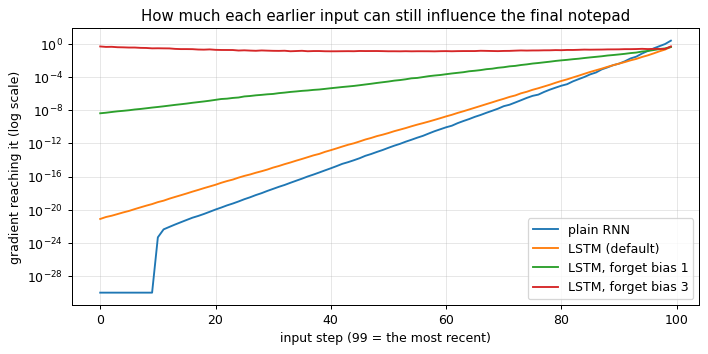

In [3]:
T = 100                                            # a 100-step sequence

def set_forget_gate_bias(lstm, value):
    # PyTorch stores an LSTM's four gate biases end to end: [input | forget | cell | output]
    hidden = lstm.hidden_size
    with torch.no_grad():
        lstm.bias_ih_l0[hidden:2 * hidden].fill_(value)   # the forget-gate slice
        lstm.bias_hh_l0[hidden:2 * hidden].fill_(0.0)
    return lstm

def gradient_reaching_each_step(layer):
    torch.manual_seed(1)
    x = torch.randn(8, T, 16, requires_grad=True)       # 8 sequences of 100 steps
    output, _ = layer(x)
    output[:, -1].sum().backward()                      # 'how does the FINAL notepad change...'
    return x.grad.norm(dim=2).mean(dim=0)               # '...when the input at each step changes?'

torch.manual_seed(0); plain_rnn = nn.RNN(16, 64, batch_first=True)
torch.manual_seed(0); lstm_default = nn.LSTM(16, 64, batch_first=True)
torch.manual_seed(0); lstm_fb1 = set_forget_gate_bias(nn.LSTM(16, 64, batch_first=True), 1.0)
torch.manual_seed(0); lstm_fb3 = set_forget_gate_bias(nn.LSTM(16, 64, batch_first=True), 3.0)

models = {"plain RNN": plain_rnn, "LSTM (default)": lstm_default,
          "LSTM, forget bias 1": lstm_fb1, "LSTM, forget bias 3": lstm_fb3}
grads = {name: gradient_reaching_each_step(layer) for name, layer in models.items()}

print(f"{'gradient reaching step':<24}" + "".join(f"{n:>22}" for n in grads))
for t in (99, 75, 50, 25, 0):
    print(f"{f'{t} ({99 - t} steps back)':<24}" + "".join(f"{g[t].item():>22.1e}" for g in grads.values()))

plt.figure(figsize=(9, 4))
for name, g in grads.items():
    plt.semilogy(range(T), g.clamp(min=1e-30), label=name)
plt.xlabel("input step (99 = the most recent)"); plt.ylabel("gradient reaching it (log scale)")
plt.title("How much each earlier input can still influence the final notepad")
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

The log scale hides how extreme this is, so read the table.

For the **plain RNN**, the gradient from 49 steps back is essentially zero — thirteen orders of
magnitude below the most recent step, and from 99 steps back it underflows to exactly 0. It can't learn anything that depends on the start of a long
sequence, because nothing from the start reaches the learning signal.

The **default LSTM** is barely better *at the start of training*. That surprises people, who have
often been told LSTMs "don't have vanishing gradients". The honest version: LSTMs **can learn**
not to have them. Out of the box, they vanish too.

Now look at the **forget-gate bias** columns. Nudging one bias from 0 to 1 raises the gradient
from far back by millions of times. At 3, the first input's influence is **about the same size
as the last one's** — nothing has vanished at all, across 100 steps.

To see why a single bias makes that much difference, we need to open up the LSTM.

## Section 4 — LSTM and GRU: Readers With Gates

The RNN's weakness is that it **rewrites its whole notepad at every step**. Old information has
to survive being squashed through `tanh` again and again, and it doesn't.

The **LSTM** ("long short-term memory") keeps a second, separate memory called the **cell
state**. Picture it as a **conveyor belt** running along the whole sequence. Information can ride
it from start to finish almost untouched, because the only things that happen to it are small,
deliberate edits controlled by three **gates**:

| Gate | Its question | Everyday version |
|---|---|---|
| **Forget gate** | How much of the belt should I **keep**? | Erase what's no longer relevant |
| **Input gate** | How much of this new step should I **write** onto the belt? | Jot down what matters |
| **Output gate** | How much of the belt should I **reveal** as this step's notepad? | Decide what to say now |

Each gate is a number between 0 and 1 for every slot in memory — 0 means "none", 1 means "all" —
computed from the current input and the previous notepad.

### Now the forget-gate bias makes sense

The forget gate is literally **the memory dial**. At 1, the belt keeps everything and gradients
flow back along it undamaged. At 0.5, it halves the memory every step, and after 50 steps
there's nothing left — the same collapse as the plain RNN.

A bias of **0** starts the gate around 0.5: forgetful. A bias of **1** starts it around 0.73; a
bias of **3** around 0.95 — "remember by default, forget only when you learn to". That's the
entire effect you saw in the table. It's a well-known trick, and it's why we'll set it in the
project.

### GRU — the streamlined version

The **GRU** ("gated recurrent unit") merges the belt and the notepad into one, and uses two gates
instead of three. It has fewer parameters, trains a little faster, and performs comparably on
many tasks. There's no universal winner; LSTM is the more common default.

In [4]:
# ── SAME INPUT, SAME NOTEPAD SIZE, THREE KINDS OF READER ─────────────────────
x = torch.randn(4, 10, 16)                          # batch of 4, 10 steps, 16 numbers each

rnn  = nn.RNN(16, 32, batch_first=True)
gru  = nn.GRU(16, 32, batch_first=True)
lstm = nn.LSTM(16, 32, batch_first=True)

_, h_rnn = rnn(x)
_, h_gru = gru(x)
_, (h_lstm, c_lstm) = lstm(x)                       # the LSTM hands back TWO memories

print("final state shapes:")
print(f"  RNN  h_n: {tuple(h_rnn.shape)}")
print(f"  GRU  h_n: {tuple(h_gru.shape)}")
print(f"  LSTM h_n: {tuple(h_lstm.shape)}   c_n: {tuple(c_lstm.shape)}  <- notepad AND conveyor belt")

count = lambda m: sum(p.numel() for p in m.parameters())
print("\nparameters (same sizes throughout):")
print(f"  RNN : {count(rnn):,}")
print(f"  GRU : {count(gru):,}   ({count(gru) / count(rnn):.0f}x — the RNN's update, plus 2 gates)")
print(f"  LSTM: {count(lstm):,}   ({count(lstm) / count(rnn):.0f}x — the update, plus 3 gates)")

final state shapes:
  RNN  h_n: (1, 4, 32)
  GRU  h_n: (1, 4, 32)
  LSTM h_n: (1, 4, 32)   c_n: (1, 4, 32)  <- notepad AND conveyor belt

parameters (same sizes throughout):
  RNN : 1,600
  GRU : 4,800   (3x — the RNN's update, plus 2 gates)
  LSTM: 6,400   (4x — the update, plus 3 gates)


Two things to take from that cell:

1. **The LSTM returns a tuple:** `output, (h_n, c_n)`. Writing `output, h_n = lstm(x)` gives you a
   confusing error, or worse, a tuple where you expected a tensor. For classification you almost
   always want `h_n[-1]`, the final notepad — not `c_n`.
2. **Each gate costs a full copy of the weights.** An LSTM is 4× the size of an RNN with the same
   hidden size; a GRU is 3×.

## Section 5 — The Memory Test

Gradients at initialisation are a clue, not a verdict. The real question is whether a model can
**learn** to use information from far back. So let's set all three an exam.

**The task:** read a sequence of random digits, and at the very end, say what the **first**
digit was.

```
input : 7 3 9 0 2 8 1 1 5 6 4 2 0 9 3 7 5 8 2 6
answer: 7
```

Everything after the first digit is noise the model must learn to ignore, and the answer has to
survive the whole journey. Guessing gets 10%.

We'll test with 20 digits, then 40. Every model gets the same budget: 3,000 training steps. The
LSTM gets forget bias 1 — the standard trick from Section 4.

In [5]:
VOCAB = 10

def make_memory_batch(n, length):
    x = torch.randint(0, VOCAB, (n, length))
    return x, x[:, 0]                                  # the label is simply the FIRST digit

class MemoryReader(nn.Module):
    def __init__(self, kind):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, 16)           # digit -> 16 numbers (Section 6)
        cell = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[kind]
        self.reader = cell(16, 64, batch_first=True)
        if kind == "LSTM":
            set_forget_gate_bias(self.reader, 1.0)     # remember by default
        self.head = nn.Linear(64, VOCAB)

    def forward(self, x):
        output, _ = self.reader(self.embed(x))
        return self.head(output[:, -1])                # answer from the FINAL notepad only

def sit_memory_test(kind, length, steps=3000, seed=0):
    torch.manual_seed(seed)
    model = MemoryReader(kind)
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(steps):
        x, y = make_memory_batch(128, length)
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # stops rare huge gradients wrecking a step
        optimizer.step()
    model.eval()
    with torch.no_grad():
        x, y = make_memory_batch(4000, length)             # fresh sequences it has never seen
        return (model(x).argmax(dim=1) == y).float().mean().item()

print("accuracy remembering the first digit (guessing = 10%):\n")
print(f"{'':<8}{'RNN':>9}{'LSTM':>9}{'GRU':>9}")
for length in (20, 40):
    start = time.time()
    scores = [sit_memory_test(kind, length) for kind in ("RNN", "LSTM", "GRU")]
    print(f"{length} digits" + "".join(f"{s:>9.1%}" for s in scores) + f"    ({time.time() - start:.0f}s)")

accuracy remembering the first digit (guessing = 10%):

              RNN     LSTM      GRU
20 digits     9.7%   100.0%   100.0%    (24s)
40 digits    10.9%    10.3%     9.7%    (46s)


### What the exam shows

**At 20 digits**, the plain RNN scores 9.7% — exactly guessing. It never learned to hold on to the first
digit, because (as Section 3 measured) almost none of the learning signal from that far back ever
reaches it. The **LSTM and GRU both score a perfect 100%**: their gates let them learn to latch on to the
first digit and ignore everything that follows.

**At 40 digits, all three fail** — back to guessing, within this training budget.

Two honest caveats, because the tidy version of this story is often told wrong:

1. **Gates help; they don't make memory unlimited.** Double the distance and even the LSTM couldn't find the
   signal in 3,000 steps. More training, careful tuning or a larger forget-gate bias might get it there,
   but it gets harder fast.
2. **Gated models can be finicky to train.** While preparing this notebook I repeated the 20-digit test with
   a different random seed: the LSTM succeeded again, but the GRU stayed stuck at guessing. Whether a model
   discovers how to use its gates can come down to luck in its starting weights.

That fragility — memory that fades with distance and has to be passed along one step at a time — is exactly
the problem Phase 8's attention gets rid of.

## Section 6 — Embeddings: Turning Words Into Numbers

A network needs numbers, and a word is not a number. The standard fix has two steps:

1. **Give every word an ID.** Build a vocabulary — `"the" -> 2`, `"movie" -> 17`, `"brilliant"
   -> 4031` — and replace each word with its ID.
2. **Look each ID up in a table of learned numbers.** Row 4031 of the table holds, say, 128
   numbers that describe "brilliant". That table is **`nn.Embedding`**.

Why not just feed the ID itself? Because ID 4031 isn't "bigger" than ID 17 in any meaningful way —
the numbers are arbitrary labels. The embedding row is different: it's **learned**. During
training, words used in similar ways drift towards similar rows. "Brilliant" and "superb" end up
close together; "brilliant" and "dreadful" end up far apart. Nobody tells the model that — it
falls out of trying to classify reviews.

Under the hood, an embedding is nothing more than a very efficient way of doing a
matrix-multiply with a one-hot vector. Let's prove it, then look at `padding_idx`.

In [6]:
torch.manual_seed(0)
embedding = nn.Embedding(num_embeddings=6, embedding_dim=4, padding_idx=0)   # 6 words, 4 numbers each
print("the table (one row per word ID):")
print(embedding.weight.data.round(decimals=2))

word_ids = torch.tensor([3, 1, 5])
looked_up = embedding(word_ids)                            # the fast way: just grab rows 3, 1, 5
print(f"\nembedding(ids {word_ids.tolist()}) -> shape {tuple(looked_up.shape)}")

# ── THE SLOW WAY THAT PROVES WHAT IT IS ──────────────────────────────────────
one_hot = nn.functional.one_hot(word_ids, num_classes=6).float()   # [0,0,0,1,0,0] etc.
via_matmul = one_hot @ embedding.weight
print("same as one-hot @ table?", torch.allclose(looked_up, via_matmul))

# ── padding_idx: ID 0 is filler, so its row stays zero and never learns ──────
print("\nrow 0 (padding) :", embedding.weight[0].tolist())
embedding(torch.tensor([0, 3])).sum().backward()
print("gradient on row 0:", embedding.weight.grad[0].tolist(), " <- padding never gets updated")
print("gradient on row 3:", embedding.weight.grad[3].tolist(), " <- a real word does")

the table (one row per word ID):
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.8500,  0.6900, -0.3200, -2.1200],
        [ 0.4700, -0.1600,  1.4400,  0.2700],
        [ 0.1700,  0.8700, -0.1400, -0.1100],
        [ 0.9300,  1.2600,  2.0000,  0.0500],
        [ 0.6200, -0.4100, -0.8400, -2.3200]])

embedding(ids [3, 1, 5]) -> shape (3, 4)
same as one-hot @ table? True

row 0 (padding) : [0.0, 0.0, 0.0, 0.0]
gradient on row 0: [0.0, 0.0, 0.0, 0.0]  <- padding never gets updated
gradient on row 3: [1.0, 1.0, 1.0, 1.0]  <- a real word does


## Section 7 — Batches of Different Lengths: Padding vs Packing

To train efficiently we process reviews in batches. But one review is 12 words and the next is 300,
and a tensor has to be rectangular.

### Padding — the obvious fix

Add filler (ID 0) to the end of the short ones until they're all as long as the longest. That makes
a rectangle. `nn.utils.rnn.pad_sequence` does it for you.

### The problem with padding alone

An RNN reads **every step it's given**. So after finishing a 12-word review, it carries on
reading 288 steps of filler, updating its notepad every time. By the end, the "final notepad" is
dominated by filler — and the actual review is a distant memory. You've just built a vanishing
gradient problem out of nothing.

### Packing — tell it where each sequence really ends

`pack_padded_sequence` bundles the padded batch **together with each sequence's true length**. The
recurrent layer then stops updating each sequence at its real end. The short review's final
notepad is taken after its last real word, exactly as if it had been processed alone.

Let's prove both claims: padding changes the answer, packing restores it exactly.

In [7]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

torch.manual_seed(0)
lstm = nn.LSTM(input_size=8, hidden_size=16, batch_first=True)

# three "sentences" of different lengths
sentences = [torch.randn(5, 8), torch.randn(3, 8), torch.randn(2, 8)]
lengths = torch.tensor([len(s) for s in sentences])

# ── THE GROUND TRUTH: EACH SENTENCE PROCESSED ON ITS OWN, NO FILLER ──────────
truth = torch.stack([lstm(s.unsqueeze(0))[1][0][-1, 0] for s in sentences])

# ── PADDED: MAKE A RECTANGLE ─────────────────────────────────────────────────
padded = pad_sequence(sentences, batch_first=True)          # (3, 5, 8): short ones get zeros on the end
print(f"padded batch: {tuple(padded.shape)}, true lengths {lengths.tolist()}")
_, (h_padded, _) = lstm(padded)

# ── PACKED: THE SAME RECTANGLE, PLUS THE TRUE LENGTHS ────────────────────────
packed = pack_padded_sequence(padded, lengths, batch_first=True, enforce_sorted=False)
_, (h_packed, _) = lstm(packed)

print("\nfinal notepad matches processing each sentence alone?")
print(f"{'':<14}{'5 words':>10}{'3 words':>10}{'2 words':>10}")
for label, h in (("padding only", h_padded[-1]), ("packed", h_packed[-1])):
    matches = [torch.allclose(h[i], truth[i], atol=1e-6) for i in range(3)]
    print(f"{label:<14}" + "".join(f"{str(m):>10}" for m in matches))

padded batch: (3, 5, 8), true lengths [5, 3, 2]

final notepad matches processing each sentence alone?
                 5 words   3 words   2 words
padding only        True     False     False
packed              True      True      True


With padding alone, only the longest sentence comes out right — it had no filler to read. The
other two are wrong, because the LSTM kept updating their notepads on zeros.

With packing, all three match processing each sentence alone, exactly. **Always pack when you use
`h_n` from a padded batch.** `enforce_sorted=False` just means you don't have to sort your batch by
length first.

## Section 8 — Project: Reading Movie Reviews

Now for the real thing. **IMDB** is 50,000 movie reviews, each labelled positive or negative —
25,000 for training and a separate 25,000 kept back for the honest test.

```
"This was one of the most tedious films I have ever sat through..."   -> negative
"A wonderful, heartfelt story with superb performances all round..."  -> positive
```

The plan, in order:

1. **Download and read** the reviews (about 80 MB, once, into the gitignored `data/` folder)
2. **Split off a validation set** — 2,500 of the training reviews, for watching progress (Phase 6:
   the test set stays sealed until the very end)
3. **Tokenize** — split each review into lowercase words
4. **Build a vocabulary** of the 20,000 most common words; everything rarer becomes `<unk>`
5. **Truncate** each review to its first 200 words, to keep training time sensible
6. **Batch** with padding, and keep the true lengths for packing
7. **Model:** embedding -> LSTM -> final notepad -> dropout -> 2 scores
8. **Train**, watching validation accuracy, then **test once** on the 25,000 unseen reviews
9. **Compare against a simple baseline** — the step people skip, and shouldn't

### Loading the data

In [8]:
import json, os, re, tarfile, urllib.request

DATA_DIR = "data"
TAR_PATH = os.path.join(DATA_DIR, "aclImdb_v1.tar.gz")
CACHE_PATH = os.path.join(DATA_DIR, "imdb_reviews.json")
URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

def load_imdb():
    # ── FAST PATH: we've already parsed it before ────────────────────────────
    if os.path.exists(CACHE_PATH):
        with open(CACHE_PATH) as fh:
            return json.load(fh)

    # ── FIRST RUN: download (~80 MB), then read the reviews straight out of the archive ──
    os.makedirs(DATA_DIR, exist_ok=True)
    if not os.path.exists(TAR_PATH):
        print("downloading IMDB (~80 MB, first run only)...")
        urllib.request.urlretrieve(URL, TAR_PATH)

    data = {"train": [], "test": []}
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        for member in tar:
            # file names look like aclImdb/train/pos/1234_9.txt
            parts = member.name.split("/")
            if len(parts) == 4 and parts[1] in data and parts[2] in ("pos", "neg"):
                text = tar.extractfile(member).read().decode("utf-8")
                data[parts[1]].append([text, 1 if parts[2] == "pos" else 0])   # 1 = positive

    with open(CACHE_PATH, "w") as fh:
        json.dump(data, fh)                      # next time, skip all of the above
    return data

imdb = load_imdb()
print(f"training reviews: {len(imdb['train']):,}    test reviews: {len(imdb['test']):,}")
print(f"positive share in training: {sum(y for _, y in imdb['train']) / len(imdb['train']):.0%}")

text, label = imdb["train"][0]
print(f"\nexample ({'positive' if label else 'negative'}):\n  {text[:300]}...")

training reviews: 25,000    test reviews: 25,000
positive share in training: 50%

example (negative):
  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...


An even 50/50 split, so **guessing gets 50%**. Anything meaningfully above that is the model
actually reading.

### Tokenizing and building a vocabulary

Our tokenizer is deliberately simple: lowercase everything, strip the `<br />` HTML tags that IMDB
reviews are full of, and keep runs of letters, digits and apostrophes. Phase 9 uses a proper
subword tokenizer; this is enough to learn from.

Two special entries sit at the front of the vocabulary: **`<pad>` = 0** for filler, and
**`<unk>` = 1** for any word too rare to make the top 20,000.

In [9]:
def tokenize(text):
    text = text.lower().replace("<br />", " ")          # IMDB reviews are full of HTML line breaks
    return re.findall(r"[a-z0-9']+", text)                # keep words, drop punctuation

all_train_tokens = [(tokenize(text), label) for text, label in imdb["train"]]
test_tokens = [(tokenize(text), label) for text, label in imdb["test"]]

# ── CARVE A VALIDATION SET OUT OF THE TRAINING REVIEWS (Phase 6) ─────────────
# Done BEFORE building the vocabulary, so validation reviews don't influence it either
shuffled = torch.randperm(len(all_train_tokens), generator=torch.Generator().manual_seed(0)).tolist()
val_ids, train_ids = shuffled[:2500], shuffled[2500:]
train_tokens = [all_train_tokens[i] for i in train_ids]
val_tokens = [all_train_tokens[i] for i in val_ids]
print(f"training {len(train_tokens):,} | validation {len(val_tokens):,} | "
      f"test {len(test_tokens):,} (sealed until the end)\n")

lengths = sorted(len(tokens) for tokens, _ in train_tokens)
print(f"review length in words: median {lengths[len(lengths) // 2]}, "
      f"90% are under {lengths[int(len(lengths) * 0.9)]}, longest {lengths[-1]}")

# ── VOCABULARY: THE 20,000 MOST COMMON TRAINING WORDS ────────────────────────
# Built from the TRAINING reviews only -- letting validation or test data shape it, even just
# through word counts, would be a quiet form of cheating
VOCAB_SIZE = 20_000
word_counts = Counter(word for tokens, _ in train_tokens for word in tokens)
itos = ["<pad>", "<unk>"] + [word for word, _ in word_counts.most_common(VOCAB_SIZE - 2)]
stoi = {word: i for i, word in enumerate(itos)}         # 'string to index'

covered = sum(word_counts[w] for w in itos[2:]) / sum(word_counts.values())
print(f"\nvocabulary of {len(itos):,} words covers {covered:.1%} of all words in the training reviews")
print("most common:", itos[2:14])

# ── WORDS -> IDs, CUT TO THE FIRST 200 ───────────────────────────────────────
MAX_LEN = 200
def encode(tokens):
    ids = [stoi.get(word, 1) for word in tokens[:MAX_LEN]]   # unknown words -> 1
    return torch.tensor(ids or [1])                          # guard against an empty review

train_set = [(encode(tokens), label) for tokens, label in train_tokens]
val_set = [(encode(tokens), label) for tokens, label in val_tokens]
test_set = [(encode(tokens), label) for tokens, label in test_tokens]

example = train_set[0][0][:12]
print(f"\nfirst 12 IDs of a training review: {example.tolist()}")
print(f"decoded back                     : {[itos[i] for i in example]}")

training 22,500 | validation 2,500 | test 25,000 (sealed until the end)

review length in words: median 174, 90% are under 458, longest 2473

vocabulary of 20,000 words covers 97.2% of all words in the training reviews
most common: ['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'was']

first 12 IDs of a training review: [1578, 11, 7, 2, 246, 17425, 17, 3, 28, 5, 2, 246]
decoded back                     : ['impressed', 'this', 'is', 'the', 'worst', 'srk', 'movie', 'and', 'one', 'of', 'the', 'worst']


### Batching: pad, and remember the true lengths

A `DataLoader` normally stacks items into a batch automatically, but it can't stack tensors of
different lengths. A **`collate_fn`** is how you tell it what to do instead: here, pad the batch
into a rectangle and hand back the true lengths alongside, ready for packing.

In [10]:
from torch.utils.data import DataLoader

def collate_reviews(batch):
    ids, labels = zip(*batch)
    lengths = torch.tensor([len(x) for x in ids])                  # true lengths, for packing
    padded = pad_sequence(ids, batch_first=True, padding_value=0)  # filler = <pad> = 0
    return padded, lengths, torch.tensor(labels)

torch.manual_seed(0)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True, collate_fn=collate_reviews)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False, collate_fn=collate_reviews)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False, collate_fn=collate_reviews)

padded, lengths, labels = next(iter(train_loader))
print(f"one batch: ids {tuple(padded.shape)}, lengths {tuple(lengths.shape)}, labels {tuple(labels.shape)}")
print(f"lengths in this batch range from {lengths.min().item()} to {lengths.max().item()} words")

one batch: ids (64, 200), lengths (64,), labels (64,)
lengths in this batch range from 35 to 200 words


### The model

Four pieces, in the order data flows through them:

```
word IDs (batch, words)
   | nn.Embedding(20000, 128)       each ID -> 128 learned numbers
(batch, words, 128)
   | pack with the true lengths     so filler is skipped
   | nn.LSTM(128, 128)              read in order, forget bias 1
final notepad h_n[-1] (batch, 128)  one summary per review
   | Dropout(0.3)                   Phase 6's anti-memorisation trick
   | nn.Linear(128, 2)
2 scores per review                 negative / positive
```

In [11]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)   # <pad> row stays zero
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        set_forget_gate_bias(self.lstm, 1.0)                                   # remember by default
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim, 2)

    def forward(self, ids, lengths):
        embedded = self.embedding(ids)                                         # (batch, words, 128)
        # pack_padded_sequence wants the lengths on the CPU, wherever the data lives
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                                        # note the tuple
        summary = h_n[-1]                                                      # final notepad, (batch, 128)
        return self.head(self.dropout(summary))                                # raw scores, no softmax

torch.manual_seed(0)
model = SentimentLSTM(VOCAB_SIZE).to(device)
n_embed = model.embedding.weight.numel()
n_total = sum(p.numel() for p in model.parameters())
print(f"total parameters: {n_total:,}")
print(f"  of which the embedding table: {n_embed:,} ({100 * n_embed / n_total:.0f}%)  <- 20,000 words x 128 numbers")

Using device: mps
total parameters: 2,692,354
  of which the embedding table: 2,560,000 (95%)  <- 20,000 words x 128 numbers


Notice where the parameters are: the vast majority sit in the **embedding table**, not the LSTM.
Learning a description of 20,000 words is most of the job.

### Training

The same five steps as every loop since Phase 3, with one addition from Section 5:
**`clip_grad_norm_`**. Recurrent networks occasionally produce one enormous gradient — the
opposite of vanishing, called *exploding* — and a single such step can wreck a model that was
training fine. Clipping caps the size of any step. It costs almost nothing and is standard practice
for RNNs.

In [12]:
EPOCHS = 4
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for ids, lengths, labels in loader:
            ids, labels = ids.to(device), labels.to(device)
            predictions = model(ids, lengths).argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

history = []
training_start = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    start, running_loss, seen = time.time(), 0.0, 0
    for ids, lengths, labels in train_loader:
        ids, labels = ids.to(device), labels.to(device)       # lengths stay on the CPU

        optimizer.zero_grad()                                  # 1. clear the tally
        scores = model(ids, lengths)                           # 2. read the reviews
        loss = loss_fn(scores, labels)                         # 3. how wrong?
        loss.backward()                                        # 4. blame
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)      #    cap any exploding step
        optimizer.step()                                       # 5. adjust

        running_loss += loss.item() * labels.size(0)
        seen += labels.size(0)

    val_acc = evaluate(model, val_loader)                      # progress check on VALIDATION
    history.append((running_loss / seen, val_acc))
    print(f"epoch {epoch}/{EPOCHS} | train loss {running_loss / seen:.3f} | "
          f"validation accuracy {val_acc:.1%} | {time.time() - start:.0f}s")

lstm_train_seconds = time.time() - training_start

# ── THE REAL EXAM: OPENED ONCE, NOW THAT TRAINING IS FINISHED ────────────────
lstm_test_acc = evaluate(model, test_loader)
print(f"\nLSTM test accuracy on 25,000 unseen reviews: {lstm_test_acc:.1%}")

epoch 1/4 | train loss 0.585 | validation accuracy 77.2% | 51s
epoch 2/4 | train loss 0.420 | validation accuracy 81.2% | 47s
epoch 3/4 | train loss 0.314 | validation accuracy 82.6% | 48s
epoch 4/4 | train loss 0.249 | validation accuracy 83.6% | 47s

LSTM test accuracy on 25,000 unseen reviews: 83.9%


Validation accuracy climbed every epoch — 77.2%, 81.2%, 82.6%, 83.6% — and the one and only look at
the test set gives **83.9% on 25,000 reviews the model had never seen.** Guessing gets 50%, so the LSTM has
clearly learned to read sentiment.

Notice how closely validation (83.6%) predicted test (83.9%): Phase 6's promise, kept. The validation curve
was still rising at epoch 4, so a few more epochs would probably help — and you'd decide how many from the
validation score, never the test score.

### Is that good? Check a simple baseline first

A number like that means nothing on its own. The habit that separates careful practitioners from
everyone else: **before celebrating a complicated model, measure the simplest reasonable model on
the same data.**

The obvious baseline here is the one Section 1 criticised — a **bag of words**. Count which words
appear, ignore their order entirely, and fit a logistic regression (a single linear layer, trained
by scikit-learn in a few seconds).

To make it a fair fight, it gets exactly what the LSTM got: the same tokenizer, the same 200-word
cut, the same 20,000-word vocabulary size, and the same 22,500 training reviews.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression

start = time.time()
bag_of_words = CountVectorizer(
    analyzer=lambda text: tokenize(text)[:MAX_LEN],   # same tokenizer, same 200-word cut
    max_features=VOCAB_SIZE,                           # same vocabulary size
    binary=True,                                       # just 'does this word appear?', order ignored
)
X_train = bag_of_words.fit_transform([imdb["train"][i][0] for i in train_ids])   # the same 22,500 reviews
y_train = [imdb["train"][i][1] for i in train_ids]
X_test = bag_of_words.transform([text for text, _ in imdb["test"]])
y_test = [label for _, label in imdb["test"]]

bow_model = LogisticRegression(C=0.1, max_iter=2000).fit(X_train, y_train)
bow_test_acc = bow_model.score(X_test, y_test)

print(f"{'':<34}{'test accuracy':>14}{'training time':>16}")
print(f"{'bag of words + logistic regression':<34}{bow_test_acc:>13.1%}{time.time() - start:>14.0f}s")
print(f"{'LSTM (reads in order)':<34}{lstm_test_acc:>13.1%}{lstm_train_seconds:>14.0f}s")

                                   test accuracy   training time
bag of words + logistic regression        85.7%             2s
LSTM (reads in order)                     83.9%           193s


**The bag of words wins: 85.7% against 83.9%** — after 2 seconds of training instead of more than three
minutes.

It's worth being clear-eyed about this, because it's the opposite of what Section 1 might lead you to
expect. A model that **cannot see word order at all** beat the model this whole notebook built.

Why? Because in movie reviews, **most of the signal lives in individual words.** A review containing
*"masterpiece"*, *"superb"* and *"loved"* is positive almost whatever order they come in; *"tedious"*,
*"waste"* and *"awful"* settle it the other way. Order only decides the harder minority — negations,
*"but"* reversals, sarcasm — and an LSTM trained from scratch on 22,500 reviews doesn't read those well
enough to make up the difference.

This isn't a failure of the lesson. It **is** the lesson:

- **Always measure a simple baseline.** Without that cell, 83.9% would have looked like a success.
- **A more sophisticated model isn't automatically a better one.** It has to earn its extra cost, on your
  data, measured.
- **Reading language well takes far more text than 22,500 reviews.** That is precisely what pretrained
  transformers bring in Phase 9: models that learned how language works from billions of words *before*
  they ever see your task.

### Where reading in order *does* matter

Aggregate accuracy hides the cases this whole notebook is about. Let's put both models side by side
on sentences built to be tricky — including Section 1's pair, which a bag of words **cannot**
tell apart even in principle.

In [14]:
def predict_sentiment(text):
    ids = encode(tokenize(text)).unsqueeze(0).to(device)       # batch of one
    lengths = torch.tensor([ids.size(1)])
    model.eval()
    with torch.no_grad():
        probabilities = torch.softmax(model(ids, lengths), dim=1)[0]   # softmax HERE, just for display
    return probabilities[1].item()                              # chance it's positive

examples = [
    "An absolute masterpiece. I loved every minute of it.",
    "A boring, predictable mess. I want those two hours back.",
    "not good just bad",
    "not bad just good",
    "I expected to hate it, but it was actually wonderful.",
    "The actors were great, but the story was dull and the ending was awful.",
]
def bag_of_words_positive(text):
    return bow_model.predict_proba(bag_of_words.transform([text]))[0, 1]

print("chance each model gives of the review being POSITIVE:\n")
print(f"{'LSTM':>7}{'bag of words':>14}   sentence")
for sentence in examples:
    print(f"{predict_sentiment(sentence):>7.1%}{bag_of_words_positive(sentence):>14.1%}   {sentence}")

chance each model gives of the review being POSITIVE:

   LSTM  bag of words   sentence
  98.0%         80.9%   An absolute masterpiece. I loved every minute of it.
   2.5%          9.4%   A boring, predictable mess. I want those two hours back.
  13.5%         33.8%   not good just bad
  29.4%         33.8%   not bad just good
  71.5%         74.5%   I expected to hate it, but it was actually wonderful.
   2.3%         20.5%   The actors were great, but the story was dull and the ending was awful.


Read the two middle rows first. The bag of words gives **exactly the same 33.8%** to *"not good just bad"*
and *"not bad just good"* — as Section 1 proved it must, since they contain the same words. It cannot tell
them apart, even in principle.

The LSTM **does** tell them apart: 13.5% for the first, 29.4% for the second. It has noticed that order
changes the meaning, and moved in the right direction. But not far enough — it still calls *"not bad just
good"* negative. Noticing a difference and understanding it are not the same thing.

Elsewhere the LSTM is consistently **more decisive**: 2.3% against 20.5% on the review that praises the
actors but slams the story, and 98.0% against 80.9% on the obvious rave. On *"I expected to hate it, but it
was actually wonderful"*, the two models essentially agree.

So the honest scorecard: the LSTM reads order in a real but limited way, and on this dataset that isn't
enough to beat counting words overall.

## Phase 7 Summary

### Cheat sheet
```
The recurrent update -- one line, repeated every step, the SAME weights each time:
  h_t = tanh(W_ih @ x_t + b_ih + W_hh @ h_(t-1) + b_hh)

Layers (ALWAYS batch_first=True):
  nn.RNN(input, hidden, batch_first=True)    output, h_n        = rnn(x)
  nn.GRU(input, hidden, batch_first=True)    output, h_n        = gru(x)
  nn.LSTM(input, hidden, batch_first=True)   output, (h_n, c_n) = lstm(x)    <- a tuple!
    output : (batch, seq, hidden)     the notepad after EVERY step -> sequence-to-sequence
    h_n    : (layers, batch, hidden)  the FINAL notepad            -> sequence-to-one: use h_n[-1]
  parameter cost: GRU = 3x an RNN, LSTM = 4x an RNN

The LSTM's gates:
  forget gate -> how much memory to KEEP        (the memory dial)
  input gate  -> how much new information to WRITE
  output gate -> how much memory to REVEAL
  forget-gate bias of 1 or more = 'remember by default' -> gradients survive much further back

Text into numbers:
  tokenize -> build vocabulary (from TRAINING data only) -> word IDs
  nn.Embedding(vocab_size, dim, padding_idx=0)   <- a learned lookup table; the pad row never trains

Batches of different lengths:
  padded = pad_sequence(seqs, batch_first=True)
  packed = pack_padded_sequence(padded, lengths.cpu(), batch_first=True, enforce_sorted=False)
  _, (h_n, _) = lstm(packed)          <- without packing, short sequences read the filler too
  DataLoader(..., collate_fn=...)     <- where the padding happens

Training recurrent models:
  nn.utils.clip_grad_norm_(model.parameters(), 1.0)    <- caps exploding gradients

What we measured:
  gradient reaching 49 steps back     : RNN 3e-13 | LSTM default 2e-11 | LSTM forget bias 3: 0.13
  remember the first of 20 digits     : RNN 9.7% (guessing) | LSTM 100% | GRU 100%
  remember the first of 40 digits     : all three back to guessing
  IMDB, 25,000 unseen test reviews    : LSTM 83.9% (193s) vs bag of words 85.7% (2s)
```

### The five things worth memorising

1. **An RNN reads in order, carrying a notepad**, and reuses the same weights at every step.
2. **Plain RNNs forget.** The LSTM's forget gate is a memory dial, and a forget-gate bias of 1 is a cheap,
   large win.
3. **`nn.LSTM` returns a tuple.** For classification use `h_n[-1]` — and always set `batch_first=True`.
4. **Pack padded batches**, or short sequences get read with their filler.
5. **Always measure a simple baseline.** Here, counting words beat the LSTM.

### Test yourself before moving on

1. Make `SentimentLSTM` bidirectional with `nn.LSTM(..., bidirectional=True)`. What shape is `h_n` now,
   and how must the head change? Does it beat the bag of words?
2. Remove `pack_padded_sequence` from `SentimentLSTM` and feed the padded embeddings straight in. Predict
   what happens to accuracy before you run it (Section 7).
3. Raise `MAX_LEN` from 200 to 400 for **both** models. Which one gains more, and what happens to the
   LSTM's training time?
4. In the memory test, give the LSTM a forget-gate bias of 3.0 and try 40 digits again.

### Up next — Phase 8: Attention & Transformers
Instead of passing a notepad down the line one word at a time, let every word look at every other word
directly. The idea behind every modern language model.